# Makine Öğrenmesine Giriş
**Kutay Kalay** · SoftITo Yapay Zeka · 21.09.2026

Üç bölüm:
1. **Regresyon:** Diyabet ilerleme skorunu tahmin etmek (Doğrusal, Ridge, Lasso)
2. **Sınıflandırma:** Tümörün iyi ya da kötü huylu olduğunu tahmin etmek (5 model, CV, GridSearch)
3. **Kümeleme:** Etiket kullanmadan K-Means ile gruplamak

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
                             silhouette_score, adjusted_rand_score)

SEED = 0
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

## 1. Regresyon: Diyabet veri seti
**Ne yapıyoruz?** 442 hastanın 10 ölçümünden (yaş, BMI, tansiyon, kan değerleri…) bir yıl sonraki hastalık ilerleme skorunu tahmin ediyoruz.
Hedef bir **sayı** olduğu için bu bir regresyon problemi.

In [2]:
diyabet = load_diabetes(as_frame=True)
X_r, y_r = diyabet.data, diyabet.target
print(X_r.shape)
X_r.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


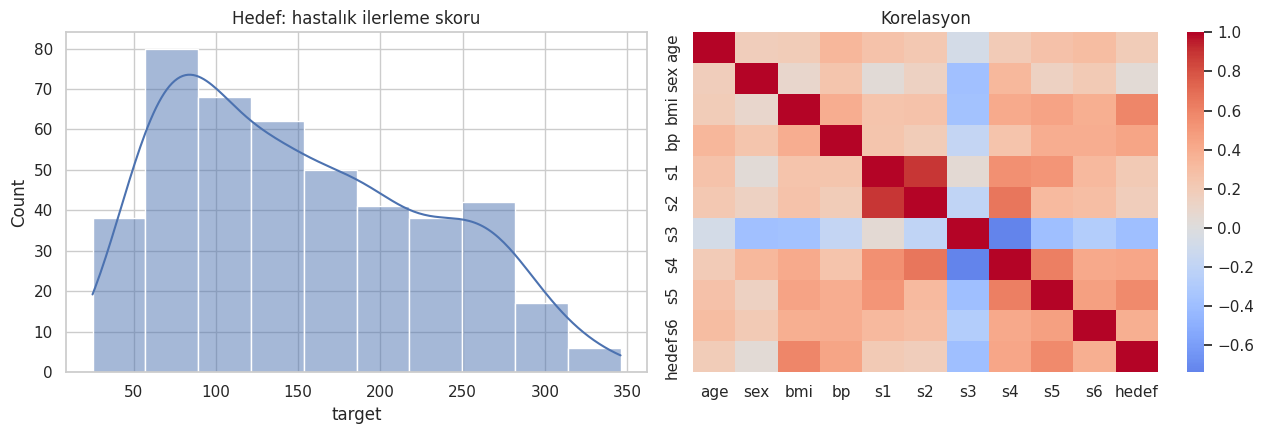

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(y_r, kde=True, ax=axes[0])
axes[0].set_title("Hedef: hastalık ilerleme skoru")
sns.heatmap(pd.concat([X_r, y_r.rename("hedef")], axis=1).corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Korelasyon")
plt.tight_layout()
plt.show()

**Neden train/test ayırıyoruz?** Modeli, hiç görmediği veride sınamak için. Sadece eğitim verisindeki başarıya bakmak, sınav sorularını önceden görmüş öğrenciyi değerlendirmek gibidir.

**Baseline (DummyRegressor):** Her hastaya ortalama değeri tahmin eden "aptal" model. Gerçek modelimiz en azından bunu geçmeli.

In [4]:
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_r, y_r, test_size=0.25, random_state=SEED)

def reg_skor(ad, model):
    tahmin = model.predict(Xr_te)
    return {"model": ad,
            "MAE": mean_absolute_error(yr_te, tahmin),
            "RMSE": np.sqrt(mean_squared_error(yr_te, tahmin)),
            "R2": r2_score(yr_te, tahmin)}

reg_modeller = {
    "Baseline (ortalama)": DummyRegressor(),
    "Doğrusal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=10)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=1.0)),
}
reg_sonuc = [reg_skor(ad, m.fit(Xr_tr, yr_tr)) for ad, m in reg_modeller.items()]
pd.DataFrame(reg_sonuc).set_index("model").round(3)

,MAE,RMSE,R2
model,,,
Baseline (ortalama),58.310,70.464,-0.000
Doğrusal,45.121,56.393,0.359
Ridge,45.145,56.453,0.358
Lasso,45.285,56.557,0.356


**Ridge ve Lasso:** Doğrusal regresyonun "frenli" halleri (düzenlileştirme).
- Ridge katsayıları küçültür.
- Lasso gereksiz gördüğü katsayıları tam **sıfır** yapar, yani değişken seçimi de yapar.

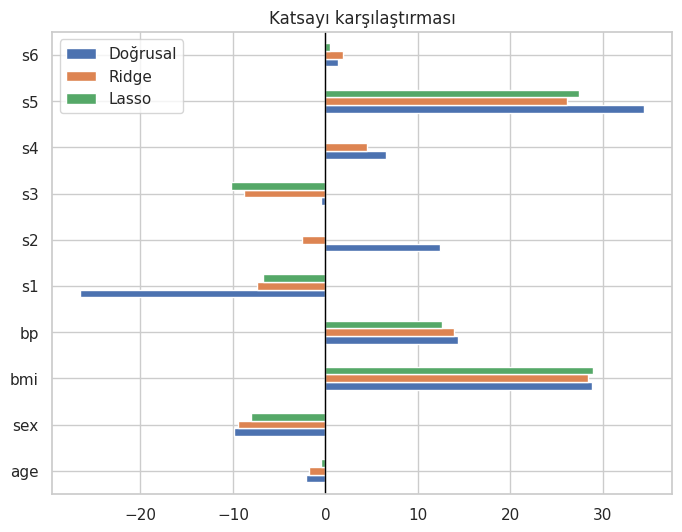

Lasso'nun sıfırladığı değişkenler: ['s2', 's4']


In [5]:
katsayilar = pd.DataFrame({
    "Doğrusal": reg_modeller["Doğrusal"][-1].coef_,
    "Ridge": reg_modeller["Ridge"][-1].coef_,
    "Lasso": reg_modeller["Lasso"][-1].coef_,
}, index=X_r.columns)

katsayilar.plot(kind="barh", figsize=(8, 6))
plt.axvline(0, color="black", lw=1)
plt.title("Katsayı karşılaştırması")
plt.show()

print("Lasso'nun sıfırladığı değişkenler:", list(katsayilar.index[katsayilar["Lasso"] == 0]))

## 2. Sınıflandırma: Meme kanseri veri seti
**Ne yapıyoruz?** 569 tümörün 30 ölçümünden tümörün kötü huylu (0) mu, iyi huylu (1) mu olduğunu tahmin ediyoruz.

`stratify=y`: Train ve test setinde sınıf oranları aynı kalsın diye kullanılıyor.

In [6]:
kanser = load_breast_cancer(as_frame=True)
X_c, y_c = kanser.data, kanser.target
print(y_c.value_counts().rename({0: "kötü huylu", 1: "iyi huylu"}))

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.25, stratify=y_c, random_state=SEED)

target
iyi huylu     357
kötü huylu    212
Name: count, dtype: int64


Beş modeli aynı veride eğitip **eğitim** ve **test** doğruluğunu yan yana koyuyoruz.
Eğitim skoru çok yüksekken test skoru belirgin şekilde düşükse model ezberlemiş (overfit) demektir.

In [7]:
siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Lojistik": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED),
}

satirlar = []
for ad, model in siniflandiricilar.items():
    model.fit(Xc_tr, yc_tr)
    satirlar.append({"model": ad,
                     "eğitim doğruluğu": model.score(Xc_tr, yc_tr),
                     "test doğruluğu": model.score(Xc_te, yc_te)})
pd.DataFrame(satirlar).set_index("model").round(3)

,eğitim doğruluğu,test doğruluğu
model,,
Baseline,0.627,0.629
Lojistik,0.991,0.958
KNN,0.979,0.951
Karar ağacı,1.000,0.902
Random Forest,0.998,0.944


**Confusion matrix:** Hangi sınıfı hangi sınıfla karıştırdığımızı gösterir.
**ROC eğrisi:** Farklı eşik değerlerinde doğru pozitif oranı ile yanlış pozitif oranı arasındaki denge. Eğri sol üst köşeye ne kadar yakınsa o kadar iyi.

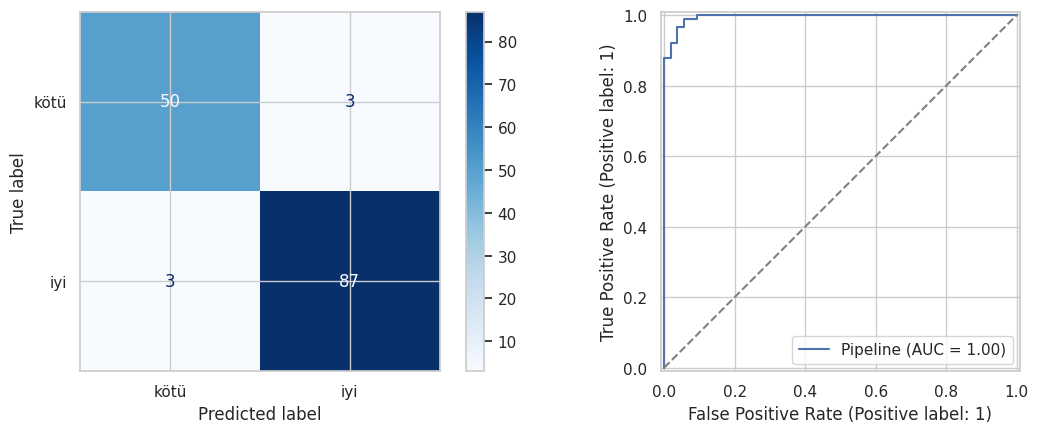

              precision    recall  f1-score   support

  kötü huylu       0.94      0.94      0.94        53
   iyi huylu       0.97      0.97      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



In [8]:
lojistik = siniflandiricilar["Lojistik"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_estimator(lojistik, Xc_te, yc_te, display_labels=["kötü", "iyi"],
                                      cmap="Blues", ax=axes[0])
RocCurveDisplay.from_estimator(lojistik, Xc_te, yc_te, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray")
plt.tight_layout()
plt.show()

print(classification_report(yc_te, lojistik.predict(Xc_te), target_names=["kötü huylu", "iyi huylu"]))

**Cross-validation:** Tek bir train/test bölmesi şansa bağlı olabilir.
Eğitim verisini 5 parçaya bölüp her seferinde birini doğrulama için ayırıyoruz ve 5 skorun ortalamasını alıyoruz.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_tablo = pd.DataFrame({
    ad: cross_val_score(model, Xc_tr, yc_tr, cv=cv) for ad, model in siniflandiricilar.items()
}).agg(["mean", "std"]).T.round(3)
cv_tablo.columns = ["ortalama", "std"]
cv_tablo.sort_values("ortalama", ascending=False)

,ortalama,std
Lojistik,0.981,0.013
Random Forest,0.967,0.013
KNN,0.967,0.026
Karar ağacı,0.927,0.026
Baseline,0.627,0.005


**GridSearchCV:** KNN'in en iyi ayarını (komşu sayısı k, ağırlıklandırma) tüm kombinasyonları CV ile deneyerek buluyoruz.
Pipeline içindeki bir adımın parametresine `adımadı__parametre` şeklinde ulaşılır.

In [10]:
arama = GridSearchCV(
    make_pipeline(StandardScaler(), KNeighborsClassifier()),
    {"kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 15, 25],
     "kneighborsclassifier__weights": ["uniform", "distance"]},
    cv=cv,
)
arama.fit(Xc_tr, yc_tr)
print("En iyi ayar :", arama.best_params_)
print("CV skoru    :", round(arama.best_score_, 3))
print("Test skoru  :", round(arama.score(Xc_te, yc_te), 3))

En iyi ayar : {'kneighborsclassifier__n_neighbors': 7, 'kneighborsclassifier__weights': 'uniform'}
CV skoru    : 0.972
Test skoru  : 0.958


### Veri sızıntısı (data leakage)
Scaler'ı **tüm veriye** fit edersek test verisinin ortalaması ve standart sapması eğitime karışır.
Farkı görmek için iki scaler'ın öğrendiği ortalamaları karşılaştırıyoruz. Doğrusu: **sadece train'e fit, test'e sadece transform**.
Pipeline kullanınca bu kural otomatik olarak uygulanır.

In [11]:
yanlis = StandardScaler().fit(X_c)
dogru = StandardScaler().fit(Xc_tr)
pd.DataFrame({"tüm veriye fit (yanlış)": yanlis.mean_[:4],
              "sadece train'e fit (doğru)": dogru.mean_[:4]},
             index=X_c.columns[:4]).round(3)

,tüm veriye fit (yanlış),sadece train'e fit (doğru)
mean radius,14.127,14.117
mean texture,19.290,19.272
mean perimeter,91.969,91.906
mean area,654.889,655.694


### Overfitting'i görmek
Gürültülü bir kosinüs eğrisine artan derecelerde polinom uyduruyoruz.
Derece arttıkça eğitim hatası hep düşer. Test hatası ise bir noktadan sonra **yükselmeye** başlar: model gürültüyü ezberliyordur.

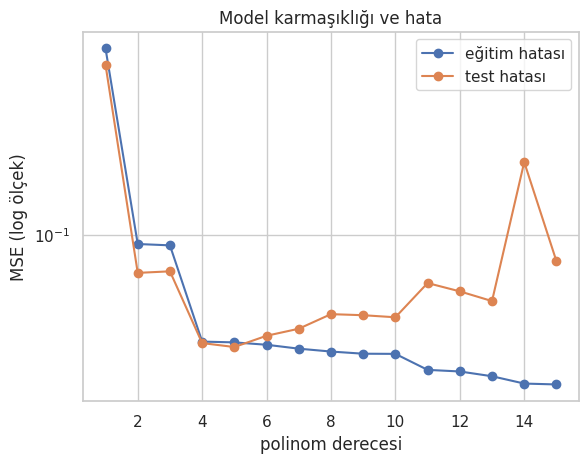

In [12]:
rng = np.random.default_rng(SEED)
x = np.sort(rng.uniform(0, 1, 50)).reshape(-1, 1)
y = np.cos(2 * np.pi * x).ravel() + rng.normal(0, 0.2, 50)
x_tr, x_te, yp_tr, yp_te = train_test_split(x, y, test_size=0.4, random_state=SEED)

dereceler = range(1, 16)
egitim_hata, test_hata = [], []
for derece in dereceler:
    model = make_pipeline(PolynomialFeatures(derece), StandardScaler(), LinearRegression()).fit(x_tr, yp_tr)
    egitim_hata.append(mean_squared_error(yp_tr, model.predict(x_tr)))
    test_hata.append(mean_squared_error(yp_te, model.predict(x_te)))

plt.plot(dereceler, egitim_hata, "o-", label="eğitim hatası")
plt.plot(dereceler, test_hata, "o-", label="test hatası")
plt.yscale("log")
plt.xlabel("polinom derecesi")
plt.ylabel("MSE (log ölçek)")
plt.legend()
plt.title("Model karmaşıklığı ve hata")
plt.show()

## 3. K-Means kümeleme
**Ne yapıyoruz?** Aynı kanser verisinde etiketleri **hiç kullanmadan** tümörleri gruplamaya çalışıyoruz.

Algoritma:
1. Rastgele k merkez seç.
2. Her noktayı en yakın merkeze ata.
3. Merkezleri, kendi grubunun ortalamasına taşı.
4. Atamalar değişmeyene kadar 2 ve 3'ü tekrarla.

k'yı seçmek için iki yönteme bakıyoruz: **Dirsek** (inertia'nın düşüşünün yavaşladığı yer) ve **Silhouette** (yüksek değer, iyi ayrışmış kümeler demek).

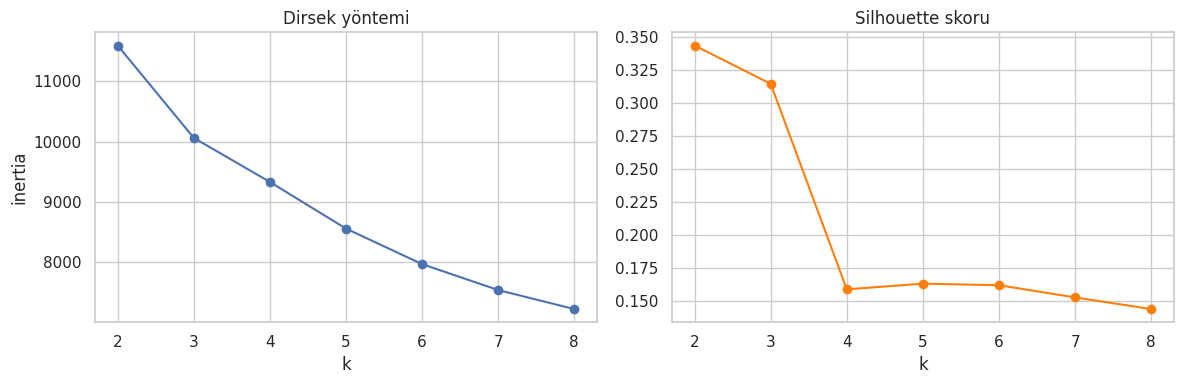

In [13]:
X_std = StandardScaler().fit_transform(X_c)

k_listesi = range(2, 9)
inertia, silhouette = [], []
for k in k_listesi:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_std)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_std, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_listesi, inertia, "o-")
axes[0].set(title="Dirsek yöntemi", xlabel="k", ylabel="inertia")
axes[1].plot(k_listesi, silhouette, "o-", color="tab:orange")
axes[1].set(title="Silhouette skoru", xlabel="k")
plt.tight_layout()
plt.show()

k = 2 ile kümeleyip sonucu **gerçek etiketlerle** karşılaştırıyoruz.
**ARI** (Adjusted Rand Index) 1'e yaklaştıkça kümeler gerçek sınıflarla daha çok örtüşür.
30 boyutlu veriyi görebilmek için PCA ile 2 boyuta indiriyoruz.

ARI: 0.654


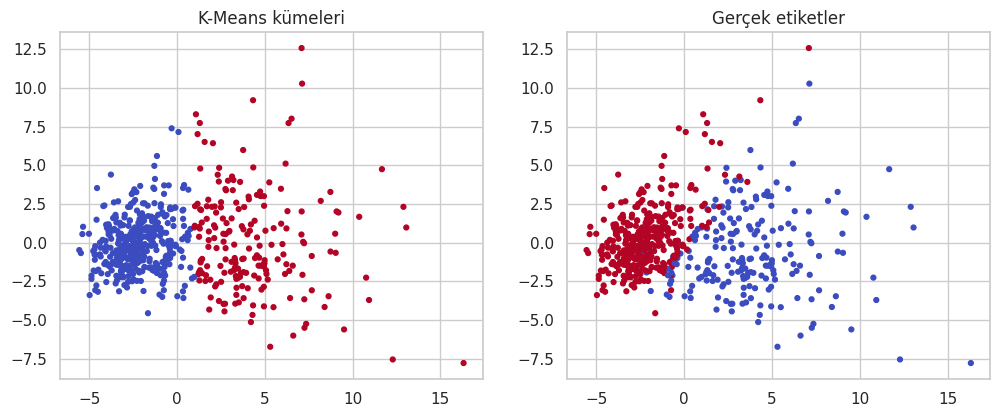

In [14]:
km2 = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_std)
print("ARI:", round(adjusted_rand_score(y_c, km2.labels_), 3))

iki_boyut = PCA(n_components=2).fit_transform(X_std)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(iki_boyut[:, 0], iki_boyut[:, 1], c=km2.labels_, cmap="coolwarm", s=12)
axes[0].set_title("K-Means kümeleri")
axes[1].scatter(iki_boyut[:, 0], iki_boyut[:, 1], c=y_c, cmap="coolwarm", s=12)
axes[1].set_title("Gerçek etiketler")
plt.show()